# Part I: Feed Analysis

#### Name: Tracy Chen, Hayley Shin (Group No: 7)

## I.1 Data Collection

Steps:
1. For each senator, retrieve the list of accounts they follow using getFollows
2. For each account in that follow list, fetch that account’s posts from the last 24 hours using getAuthorFeed
3. Combine these posts into a single reverse-chronological feed for each senator
4. Save the data as JSON (one file per senator, or one combined file)

In [3]:
# Import libraries
import time
from bluesky_helpers import (
    load_senators, get_all_follows, get_author_feed,
    is_within_hours, save_json, load_json
)

In [8]:
from tqdm import tqdm 

## Step 1: Collect follows for each senator
senators = load_senators('senators_bluesky.csv')
follows_data = {}
follows_file = 'senator_follows.json'
for senator in tqdm(senators, desc="Collecting follows"):
    handle = senator['handle']
    follows = get_all_follows(handle)
    follows_data[handle] = follows
    time.sleep(0.1)

save_json(follows_data, 'PartI1_senator_follows.json')

In [9]:
## Step 2: Collect posts from followed accounts (last 24 hours)

follows_data = load_json('PartI1_senator_follows.json')

# Get all unique handles from follow lists
all_followed_accounts = set()
for senator_handle, follows_list in follows_data.items():
    for followed_account in follows_list:
        handle = followed_account.get('handle')
        if handle:
            all_followed_accounts.add(handle)

print(f"Total unique accounts to fetch: {len(all_followed_accounts)}")

# Fetch posts from each account, filtering to last 24 hours
posts_file = 'PartI1_posts_data.json'
posts_data = {}

for handle in tqdm(all_followed_accounts, desc="Collecting posts"):
    feed_response = get_author_feed(handle)

    if feed_response and 'feed' in feed_response:
        recent_posts = []
        for item in feed_response['feed']:
            post = item.get('post', {})
            created_at = post.get('record', {}).get('createdAt', '')

            if is_within_hours(created_at, hours=24):  
                recent_posts.append(post)
        posts_data[handle] = recent_posts
    else:
        posts_data[handle] = []

    time.sleep(0.1)

save_json(posts_data, posts_file)
print(f"Done! Saved {len(posts_data)} accounts to {posts_file}")

Total unique accounts to fetch: 2308


Done! Saved 2308 accounts to PartI1_posts_data.json


In [12]:
## Step 3: Combine into reverse-chronological feed for each senator 
feeds_data = {}
feed_file = 'PartI1_feeds_data.json'


for senator in tqdm(senators, desc="Compiling feeds for senators"):
    handle = senator['handle']
    senator_follows = follows_data.get(handle, [])
    
    # Collect all posts from accounts this senator follows
    feed_posts = []
    for followed in senator_follows:
        followed_handle = followed.get('handle')
        if followed_handle and followed_handle in posts_data:
            feed_posts.extend(posts_data[followed_handle])
    
    # Sort by created_at in reverse chronological order (newest first)
    feed_posts.sort(key=lambda x: x.get('record', {}).get('createdAt', ''), reverse=True)
    
    feeds_data[handle] = feed_posts

save_json(feeds_data, feed_file)
print(f"Saved feeds to {feed_file}")

Compiling feeds for senators: 100%|██████████| 42/42 [00:00<00:00, 2089.66it/s]


Saved feeds to PartI1_feeds_data.json


## I.2 “Senators You May Know” Recommendations

Build a simple recommendation system to suggest which senators each senator should follow, based on the follow graph among senators. Use a **triangle-counting approach**: for each senator X who doesn’t follow senator Y, count how many senators that X does follow also follow Y. This is the “mutual follows” count — the more senators in X’s network who follow Y, the stronger the recommendation.

recommendation_score(A, B) = |{C : A follows C and C follows B}| (A do not follow B and r_score(A,B) $\neq$ r_score(B,A))

For each senator:

1. Identify which other senators they do not currently follow
2. For each non-followed senator, compute the recommendation score (number of followed senators who follow them)
3. Report the top 3 recommendations with their scores
If a senator already follows all other senators, note this in your output. If a senator follows no other senators, note this in your output.

In [4]:
# some helper functions for Part 2 

# create the senator graph from follows data. key: senator handle; value: set of handles that this senator follows 
def create_senator_graph(follows_data, valid_handles):
    senator_graph = {}
    for handle, followed_list in follows_data.items():
        if handle not in valid_handles:
            continue
            
        follows = set()
        for followed in followed_list:
            followed_handle = followed.get('handle')
            if followed_handle in valid_handles:
                follows.add(followed_handle)
        
        senator_graph[handle] = follows
    return senator_graph
    

# return -1 if senator1 == senator2; -2 if senator1 already follows senator2
# else return the recommendation score
def calculate_recommendation_score(senator1, senator2, senator_graph):
    score = 0
    follows1 = senator_graph.get(senator1, set())
    if senator1 == senator2:
        return -1 
    if senator2 in follows1:
        return -2
    for c in follows1:
        c_follows = senator_graph.get(c, set())
        if senator2 in c_follows:
            score += 1
    return score 

# transfer the handles from API to acutal senator names 
def get_name_map(senators):
    return {s['handle']: s['name'] for s in senators}

def print_information(set, name_map):
    for senator_handle in set:
        senator_name = name_map[senator_handle]
        print(f"{senator_name} (@{senator_handle})")


In [5]:
import pandas as pd

senators = load_senators('senators_bluesky.csv')
follows_data = load_json('PartI1_senator_follows.json')

valid_handles = {s['handle'] for s in senators}
senator_graph = create_senator_graph(follows_data, valid_handles)
name_map = get_name_map(senators)

follows_no_others = set()
follows_all_others = set()
recommendations = {}  # Store recommendations for each senator

for s1 in valid_handles:
    already_following_count = len(senator_graph.get(s1, set()))
    if already_following_count == 0:
        follows_no_others.add(s1)
        continue
    elif already_following_count == len(valid_handles) - 1:
        follows_all_others.add(s1)
        continue

    candidates = []
    for s2 in valid_handles:
        score = calculate_recommendation_score(s1, s2, senator_graph)
        if score > 0:
            candidates.append((score, s2))

    candidates.sort(key=lambda x: (-x[0], x[1]))
    top_3 = candidates[:3]
    recommendations[s1] = top_3

print("\nSenators who follow all other senators:")
print_information(follows_all_others, name_map)
print("\nSenators who follow no other senators:")
print_information(follows_no_others, name_map)

# compute reverse graph: for each senator, who follows them
followed_by_count = {h: 0 for h in valid_handles}
for s1, follows_set in senator_graph.items():
    for s2 in follows_set:
        followed_by_count[s2] += 1

followed_by_all = {h for h, count in followed_by_count.items() if count == len(valid_handles) - 1}
followed_by_zero = {h for h, count in followed_by_count.items() if count == 0}


print("\nSenators followed by all other senators:")
print_information(followed_by_all, name_map)
print("\nSenators followed by zero other senators:")
print_information(followed_by_zero, name_map)

print("\nTop 3 follow recommendations for other senators:")
table_data = []
for senator_handle, top_3 in recommendations.items():
    senator_name = name_map[senator_handle]
    row = [senator_name]
    for score, rec_handle in top_3:
        rec_name = name_map[rec_handle]
        row.append(f"{rec_name} ({score})")
    # Pad with empty strings if less than 3 recommendations
    while len(row) < 4:
        row.append("")
    table_data.append(row)

# Create DataFrame and display
df = pd.DataFrame(table_data, columns=['Senator', 'Recommendation 1', 'Recommendation 2', 'Recommendation 3'])
df = df.sort_values('Senator').reset_index(drop=True)
print(df.to_string(index=False))

# Save to CSV
df.to_csv('PartI2_recommendation.csv', index=False)
print("\nSaved recommendations to PartI2_recommendation.csv")


Senators who follow all other senators:

Senators who follow no other senators:
John Fetterman (@fetterman.senate.gov)
Jeff Merkley (@jeff-merkley.bsky.social)
Chris Murphy (@chrismurphyct.bsky.social)
Mark Kelly (@captmarkkelly.bsky.social)
Kirsten Gillibrand (@kirstengillibrand.bsky.social)
Bernie Sanders (@sanders.senate.gov)
Maggie Hassan (@hassan.senate.gov)

Senators followed by all other senators:

Senators followed by zero other senators:
Kirsten Gillibrand (@kirstengillibrand.bsky.social)

Top 3 follow recommendations for other senators:
             Senator          Recommendation 1      Recommendation 2          Recommendation 3
         Adam Schiff            Ed Markey (17)     Brian Schatz (17)       Michael Bennet (16)
        Alex Padilla        Tammy Baldwin (13)      Adam Schiff (12)       Jeanne Shaheen (12)
       Amy Klobuchar             Andy Kim (16)   Elissa Slotkin (16)         Maggie Hassan (4)
            Andy Kim       Jeanne Shaheen (19)  Raphael Warnock (1

## I.3 Echo Chamber Analysis

Examine the degree to which senators’ feeds overlap using two complementary measures:
- Follow Jaccard Similarity Jaccard(A, B) = |follows_A ∩ follows_B| / |follows_A ∪ follows_B|
- Post Jaccard Similarity 

In [11]:

def get_followers(senator, follows_data):
    followers = set()
    for f in follows_data.get(senator, []):
        handle = f.get('handle')
        if handle:
            followers.add(handle)
    return followers

def follow_jaccard_similarity(senator1, senator2, follows_data):
    
    follows1 = get_followers(senator1, follows_data)
    follows2 = get_followers(senator2, follows_data)
    
    intersection = follows1 & follows2
    union = follows1 | follows2
    
    if not union:
        return 0.0
    return len(intersection) / len(union)

def get_post_ids(senator, feeds_data):
    posts = feeds_data.get(senator, [])
    post_ids = set()
    for post in posts:
        if 'uri' in post:
            post_ids.add(post['uri'])
    return post_ids

def post_jaccard_similarity(senator1, senator2, feeds_data):
  
    post_ids1 = get_post_ids(senator1, feeds_data)
    post_ids2 = get_post_ids(senator2, feeds_data)
    
    intersection = post_ids1 & post_ids2
    union = post_ids1 | post_ids2
    
    if not union:
        return 0.0
    return len(intersection) / len(union)


def build_similarity_matrix(senators, similarity_func, data):    
    handles = [s['handle'] for s in senators]
    n = len(handles)
    matrix = np.zeros((n, n))
    
    for i, h1 in enumerate(handles):
        for j, h2 in enumerate(handles):
            if i == j:
                matrix[i, j] = 1.0
            elif i < j:
                sim = similarity_func(h1, h2, data)
                matrix[i, j] = sim
                matrix[j, i] = sim  # Symmetric
    
    return matrix, handles

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


def cluster_order(matrix):
    distance_matrix = 1 - matrix
    np.fill_diagonal(distance_matrix, 0)
    condensed_dist = squareform(distance_matrix)
    linkage_matrix = linkage(condensed_dist, method='average')
    return leaves_list(linkage_matrix)


def create_heatmap(matrix, labels, name_map, title, ax, order):
    reordered_matrix = matrix[np.ix_(order, order)]
    reordered_labels = [name_map.get(labels[i], labels[i]) for i in order]
    
    im = ax.imshow(reordered_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(reordered_labels)))
    ax.set_yticks(range(len(reordered_labels)))
    ax.set_xticklabels(reordered_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(reordered_labels, fontsize=8)
    ax.set_title(title, fontsize=14)
    
    plt.colorbar(im, ax=ax, label='Jaccard Similarity')

Unsorted Heatmaps (original order):


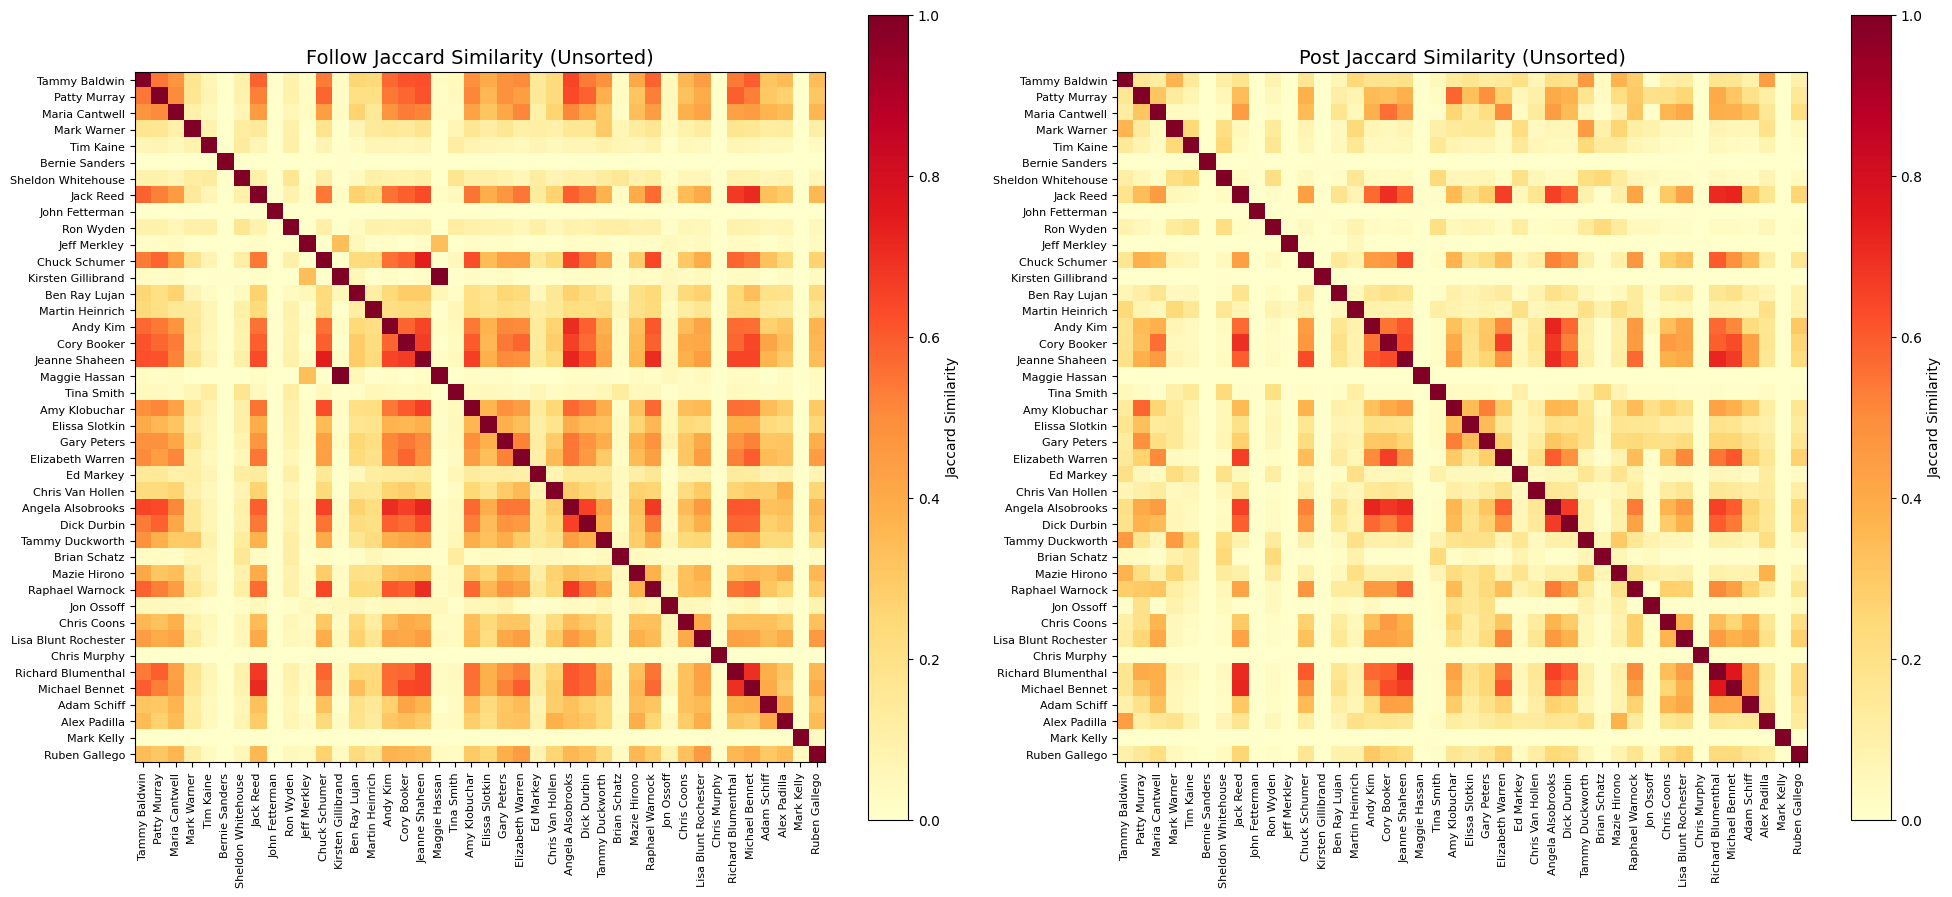


Sorted Heatmaps (hierarchical clustering):


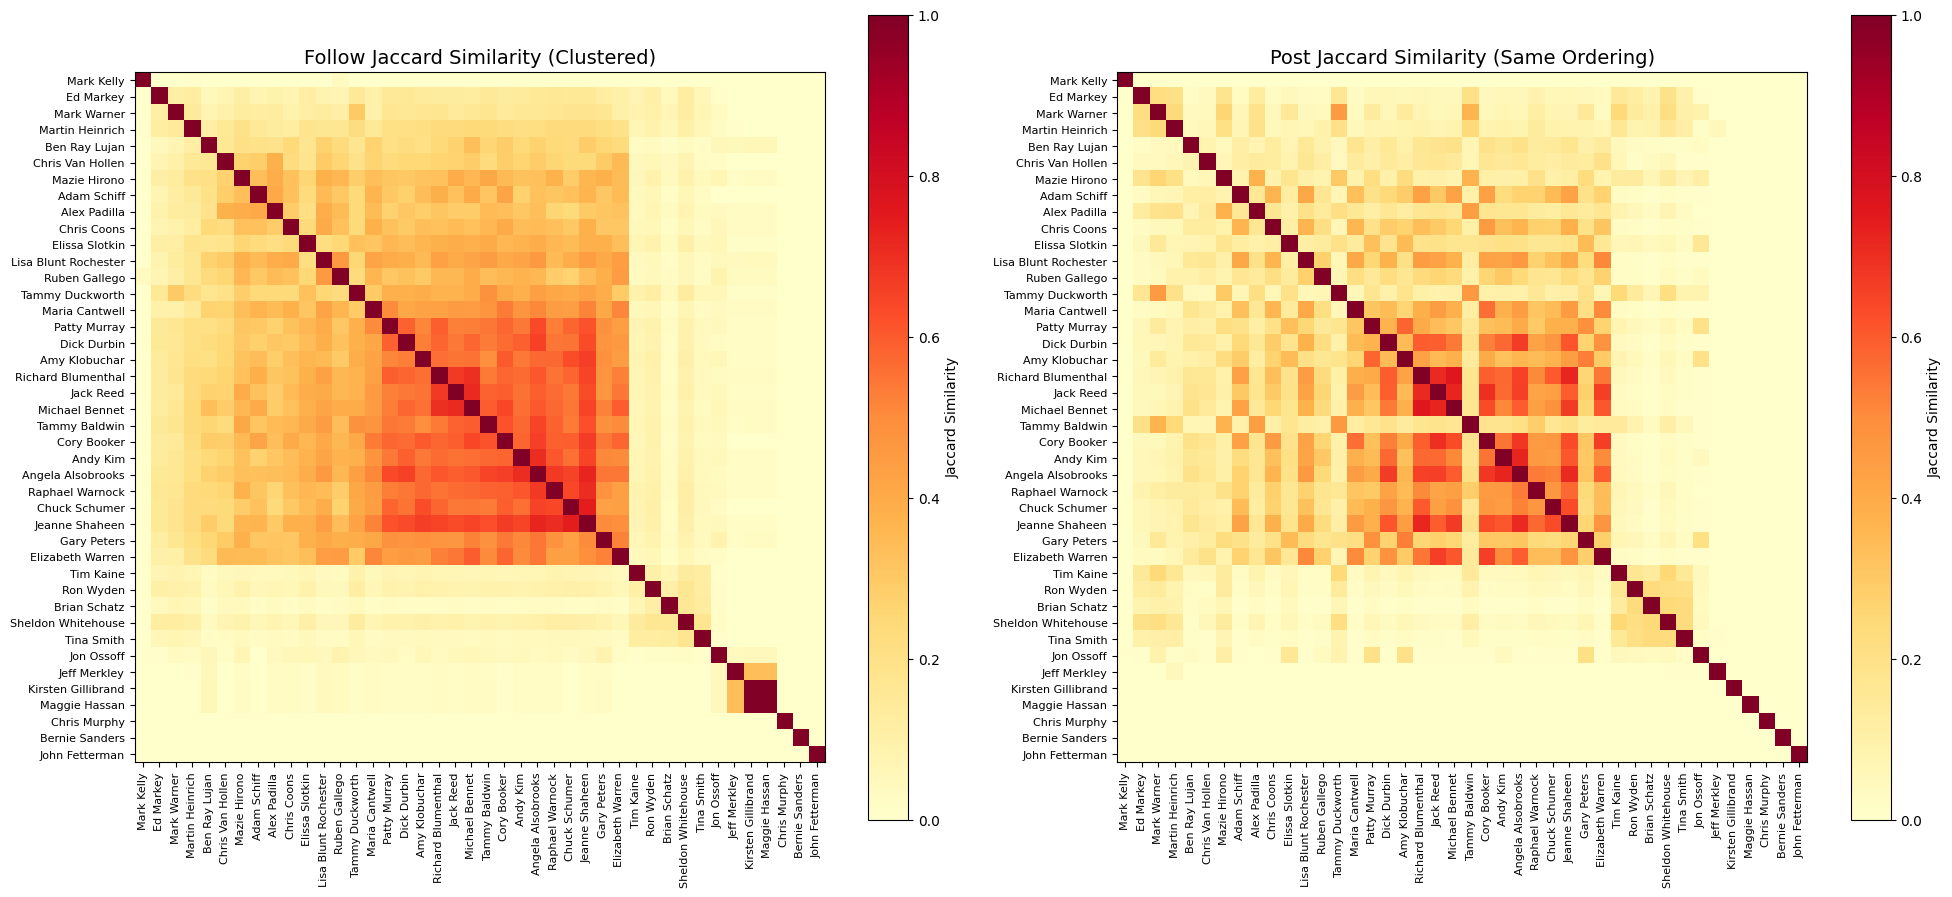

In [12]:
import numpy as np
import matplotlib.pyplot as plt

senators = load_senators('senators_bluesky.csv')
follows_data = load_json('PartI1_senator_follows.json')
feeds_data = load_json('PartI1_feeds_data.json')
name_map = get_name_map(senators)

follow_matrix, handles = build_similarity_matrix(senators, follow_jaccard_similarity, follows_data)
post_matrix, _ = build_similarity_matrix(senators, post_jaccard_similarity, feeds_data)

print("Unsorted Heatmaps (original order):")
fig1, axes1 = plt.subplots(1, 2, figsize=(20, 9))
original_order = list(range(len(handles)))

create_heatmap(follow_matrix, handles, name_map,'Follow Jaccard Similarity (Unsorted)', axes1[0], original_order)
create_heatmap(post_matrix, handles, name_map,'Post Jaccard Similarity (Unsorted)', axes1[1], original_order)

plt.tight_layout()
plt.savefig('PartI3_heatmaps_unsorted.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSorted Heatmaps (hierarchical clustering):")
fig2, axes2 = plt.subplots(1, 2, figsize=(20, 9))
order = cluster_order(follow_matrix)
create_heatmap(follow_matrix, handles, name_map,'Follow Jaccard Similarity (Clustered)', axes2[0], order)
create_heatmap(post_matrix, handles, name_map,'Post Jaccard Similarity (Same Ordering)', axes2[1], order)

plt.tight_layout()
plt.savefig('PartI3_heatmaps_clustered.png', dpi=150, bbox_inches='tight')
plt.show()


## I.4 Reflection Questions

In [ ]:
## I.4 Supporting Data

from collections import Counter

print("Top 3 Recommender from Part 2")
rec_count = Counter()
for s1, top_3 in recommendations.items():
    for score, s2 in top_3:
        rec_count[s2] += 1
rec_table = []
for handle, count in rec_count.most_common():
    rec_table.append([name_map[handle], count])
rec_df = pd.DataFrame(rec_table, columns=['Senator', 'Appears in N top-3 lists'])
print(rec_df.head(10).to_string(index=False))

print("Feed Volume per Senator")
vol_table = []
for s in senators:
    h = s['handle']
    n_follows = len(follows_data.get(h, []))
    n_posts = len(feeds_data.get(h, []))
    vol_table.append([s['name'], n_follows, n_posts])
vol_df = pd.DataFrame(vol_table, columns=['Senator', 'Follows', 'Posts in Feed'])
vol_df = vol_df.sort_values('Posts in Feed', ascending=False).reset_index(drop=True)
print(vol_df.head(10).to_string(index=False))

print("Most Followed by Other Senators (top 10)")
followed_by = Counter()
for s1, fset in senator_graph.items():
    for s2 in fset:
        followed_by[s2] += 1
for handle, count in followed_by.most_common(10):
    print(f"  {name_map[handle]:>25}: followed by {count} senators")

Top 3 Recommender from Part 2
        Senator  Appears in N top-3 lists
    Dick Durbin                         9
      Jack Reed                         7
 Elissa Slotkin                         7
Tammy Duckworth                         6
       Andy Kim                         6
  Tammy Baldwin                         5
   Jeff Merkley                         5
 John Fetterman                         4
    Adam Schiff                         4
 Jeanne Shaheen                         4

=== Feed Volume per Senator ===
           Senator  Follows  Posts in Feed
        Tina Smith      891           5212
      Brian Schatz      564           3476
         Ron Wyden      376           2659
Sheldon Whitehouse      401           2080
         Tim Kaine      538           1616
         Ed Markey      218           1071
       Mark Warner      102            659
   Martin Heinrich      106            646
   Tammy Duckworth       76            602
      Mazie Hirono       42            343

=